<a href="https://colab.research.google.com/github/Rijwan94/DS_Pyhton_M2/blob/main/Applied_Statistics_Project_PBA_Rijwan_Shaikh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Purchase Behavior Analysis using Descriptive Statistics

- Rijwan Shaikh

##Problem Statement

🔍 **Problem Statement**:

Welcome to the Probability and Statistics project! 📊🔍 In this exciting journey, you'll get the chance to apply the concepts you've learned in probability theory and statistics to analyze a real-world dataset. This project is your opportunity to dive deep into the world of data analysis and gain practical experience with the tools and techniques you've been learning. 🚀

🎯 **Objective**:

Your mission is to analyze the provided dataset containing customer information and purchasing behavior to make informed decisions. Your goal is to identify patterns, trends, and correlations that will help your company optimize its marketing efforts and increase offer acceptance rates. 🎉

##About the Dataset



Here's the link to the [dataset](https://docs.google.com/spreadsheets/d/12ln9iTNcVNOMYi_AU-OczKpa_KIP8XyVbsjk81Na8Yk/edit?usp=sharing)


This data was gathered during last year's campaign.
Data description is as follows;

1. Response (target) - 1 if customer accepted the offer in the last campaign, 0 otherwise
1. ID - Unique ID of each customer
1. Year_Birth - Age of the customer
1. Complain - 1 if the customer complained in the last 2 years
1. Dt_Customer - date of customer's enrollment with the company
1. Education - customer's level of education
1. Marital - customer's marital status
1. Kidhome - number of small children in customer's household
1. Teenhome - number of teenagers in customer's household
1. Income - customer's yearly household income
1. MntFishProducts - the amount spent on fish products in the last 2 years
1. MntMeatProducts - the amount spent on meat products in the last 2 years
1. MntFruits - the amount spent on fruits products in the last 2 years
1. MntSweetProducts - amount spent on sweet products in the last 2 years
1. MntWines - the amount spent on wine products in the last 2 years
1. MntGoldProds - the amount spent on gold products in the last 2 years
1. NumDealsPurchases - number of purchases made with discount
1. NumCatalogPurchases - number of purchases made using catalog (buying goods to be shipped through the mail)
1. NumStorePurchases - number of purchases made directly in stores
1. NumWebPurchases - number of purchases made through the company's website
1. NumWebVisitsMonth - number of visits to company's website in the last month
1. Recency - number of days since the last purchase





##Task 1 - Basic CleanUp

- **Clean and preprocess the dataset (handling missing values, data types, etc.).**

- **Analyze the distribution of customer demographics (age, education, marital status) using descriptive statistics and visualizations.**



**Deliverables**:

- **Cleaned and Preprocessed Dataset**:

  Provide a detailed report on the steps taken to handle missing values, including imputation methods used if applicable.
  Document the process of ensuring consistent data types for each variable, addressing any inconsistencies.

- **Summary of Basic Statistics**:

  Present calculated statistics such as mean, median, variance, and standard deviation for each relevant numerical variable.
  Include a concise table or summary showcasing these measures for easy reference.

#Load Dataset

###Required Libraries

In [87]:
#Import Libraries
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np
from scipy.stats import binom, norm
from scipy.stats import poisson
from scipy.stats import expon
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew, kurtosis, shapiro
from scipy.stats.mstats import winsorize
from scipy import stats
%matplotlib inline

Connect Drive

In [88]:
#Connect drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Load CSV File / Dataset

In [89]:
#Load CSV File
PBA_df = pd.read_csv('/content/drive/MyDrive/Data Science/5. Applied Statistics/Mid Course/Superstore Marketing Data - Sheet1.csv', encoding='latin-1')


In [90]:
#First look of Dataframe PBA_df
PBA_df


,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,Together,32474.0,1,1,########,0,10,...,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,Single,21474.0,1,0,########,0,6,...,11,0,34,2,3,1,2,7,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,########,99,372,...,47,48,78,2,5,2,11,4,0,0
2236,5263,1977,2n Cycle,Married,31056.0,1,0,1/22/2013,99,5,...,3,8,16,1,1,0,3,8,0,0
2237,22,1976,Graduation,Divorced,46310.0,1,0,########,99,185,...,15,5,14,2,6,1,5,8,0,0
2238,528,1978,Graduation,Married,65819.0,0,0,11/29/2012,99,267,...,149,165,63,1,5,4,10,3,0,0


In [91]:
# Get the number of rows and columns
rows, cols = PBA_df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")


Number of rows: 2240
Number of columns: 22


In [92]:
#Summary of PBA_df

print(PBA_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [93]:
# Check for missing values
print(PBA_df.isnull().sum())


Id                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Response                0
Complain                0
dtype: int64


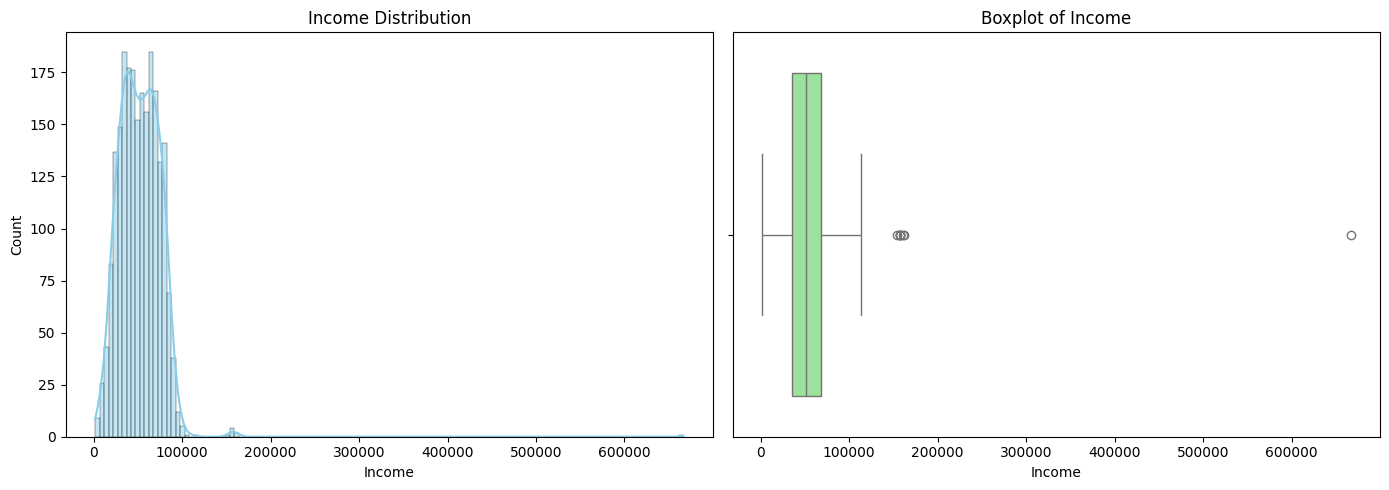

Mean Income: 52247.25
Median Income: 51381.5
Mode Income: 7500.0
Skewness: 6.76

✅ Based on the skewed distribution, MEDIAN is selected to impute missing values.

Missing values in 'Income' 24


In [94]:
# Analyze and Impute Income Column

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# 1. Visualize Income Distribution
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(PBA_df['Income'], kde=True, color='skyblue')
plt.title('Income Distribution')
plt.xlabel('Income')

plt.subplot(1, 2, 2)
sns.boxplot(x=PBA_df['Income'], color='lightgreen')
plt.title('Boxplot of Income')

plt.tight_layout()
plt.show()

# 2. Summary Statistics
income_mean = PBA_df['Income'].mean()
income_median = PBA_df['Income'].median()
income_mode = PBA_df['Income'].mode()[0]
income_skew = skew(PBA_df['Income'].dropna())

print("Mean Income:", round(income_mean, 2))
print("Median Income:", round(income_median, 2))
print("Mode Income:", income_mode)
print("Skewness:", round(income_skew, 2))

# 3. Based on analysis, MEDIAN is the best method
print("\n✅ Based on the skewed distribution, MEDIAN is selected to impute missing values.")

# 4. Confirm Imputation
print("\nMissing values in 'Income'", PBA_df['Income'].isnull().sum())


In [95]:
PBA_df['Income'] = PBA_df['Income'].fillna(income_median)

In [96]:
# 4. Confirm Imputation
print("\nMissing values in 'Income' after imputation:", PBA_df['Income'].isnull().sum())


Missing values in 'Income' after imputation: 0


In [97]:
#Add new 'Age' Column to the df for better understanding
#Calculate today's date
today = datetime.today().year

# Function to calculate age
def calculate_age(year_birth):
    return today - year_birth

# Apply the function to create the 'Age' column
PBA_df['Age'] = PBA_df['Year_Birth'].apply(calculate_age)


In [98]:
# Display 'Year_Birth' and added column 'Age'
print(PBA_df[['Year_Birth', 'Age']])

      Year_Birth  Age
0           1970   55
1           1961   64
2           1958   67
3           1967   58
4           1989   36
...          ...  ...
2235        1976   49
2236        1977   48
2237        1976   49
2238        1978   47
2239        1969   56

[2240 rows x 2 columns]


In [99]:
#Final look on df
PBA_df

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,189,218,1,4,4,6,1,1,0,55
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,0,37,1,7,3,7,5,1,0,64
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,2,30,1,3,2,5,2,0,0,67
3,1386,1967,Graduation,Together,32474.0,1,1,########,0,10,...,0,0,1,1,0,2,7,0,0,58
4,5371,1989,Graduation,Single,21474.0,1,0,########,0,6,...,0,34,2,3,1,2,7,1,0,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,########,99,372,...,48,78,2,5,2,11,4,0,0,49
2236,5263,1977,2n Cycle,Married,31056.0,1,0,1/22/2013,99,5,...,8,16,1,1,0,3,8,0,0,48
2237,22,1976,Graduation,Divorced,46310.0,1,0,########,99,185,...,5,14,2,6,1,5,8,0,0,49
2238,528,1978,Graduation,Married,65819.0,0,0,11/29/2012,99,267,...,165,63,1,5,4,10,3,0,0,47


In [100]:
# Convert the 'Dt_Customer' column to datetime
PBA_df['Dt_Customer'] = pd.to_datetime(PBA_df['Dt_Customer'], errors='coerce')

In [101]:
missing_values = PBA_df['Dt_Customer'].isnull().sum()
print(missing_values)

916


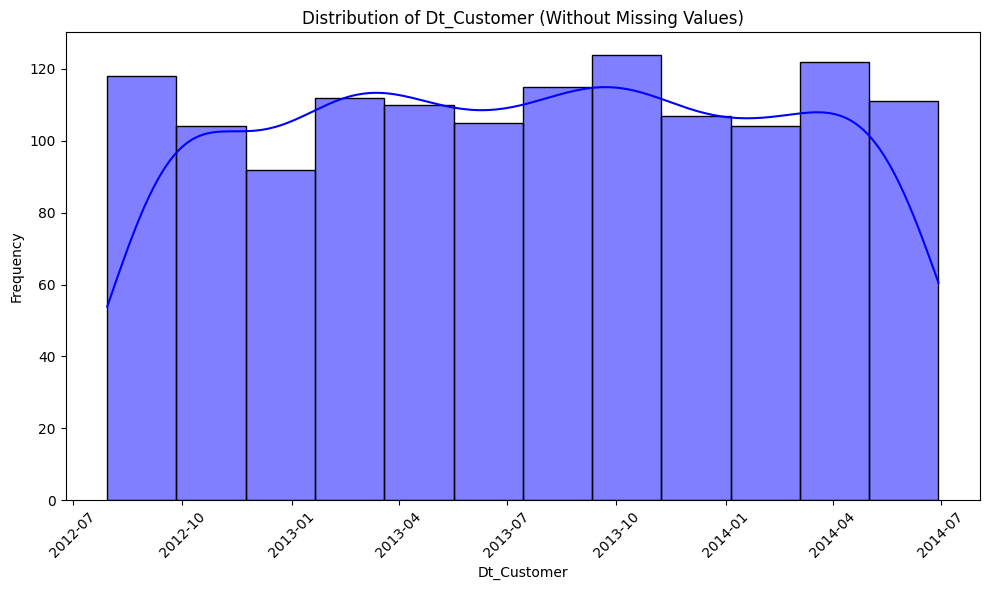

### 🗂 Column Analyzed: 'Dt_Customer'

- 📅 Most Frequent Date (Mode): 2012-08-31
- 🔢 Occurrences of Mode: 12
- 📊 Percentage of Mode in Total Non-Null Rows: 0.91%
- 📈 Skewness of Data: -0.01

#### ✅ Conclusion:
- The data is **relatively balanced**.
- There is **no clear skew or dominant mode**.
### 🔧 Recommended Imputation Method:
👉 Use the **median date** → 2013-07-21 for imputing missing values in 'Dt_Customer'.


In [102]:
# Column to analyze for Method to be used for Imputation for Dt_Customer
date_column = 'Dt_Customer'

# Step 1: Check for skewness
skewness = PBA_df[date_column].dropna().apply(lambda x: x.timestamp()).skew()

# Step 2: Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(PBA_df[date_column].dropna(), kde=True, color='blue')
plt.title(f"Distribution of {date_column} (Without Missing Values)")
plt.xlabel(date_column)
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 3: Calculate mode, count, and percentage
mode_value = PBA_df[date_column].mode()[0]
mode_count = PBA_df[date_column].value_counts()[mode_value]
total_count = PBA_df[date_column].notna().sum()
mode_percentage = (mode_count / total_count) * 100
median_value = PBA_df[date_column].median()

# Step 4: Final report with recommendation
print("### 🗂 Column Analyzed: 'Dt_Customer'\n")
print(f"- 📅 Most Frequent Date (Mode): {mode_value.date()}")
print(f"- 🔢 Occurrences of Mode: {mode_count}")
print(f"- 📊 Percentage of Mode in Total Non-Null Rows: {mode_percentage:.2f}%")
print(f"- 📈 Skewness of Data: {skewness:.2f}\n")

print("#### ✅ Conclusion:")

if abs(skewness) > 0.5:
    print("- The data is **skewed**.")
    print("- The mode appears in less than 10% of the data and does not dominate.")
    print("### 🔧 Recommended Imputation Method:")
    print(f"👉 Use the **median date** → {median_value.date()} for imputing missing values in 'Dt_Customer'.")
elif mode_percentage > 10:
    print("- The data has a **dominant date value**.")
    print(f"### 🔧 Recommended Imputation Method:")
    print(f"👉 Use the **mode date** → {mode_value.date()} for imputing missing values in 'Dt_Customer'.")
else:
    print("- The data is **relatively balanced**.")
    print("- There is **no clear skew or dominant mode**.")
    print("### 🔧 Recommended Imputation Method:")
    print(f"👉 Use the **median date** → {median_value.date()} for imputing missing values in 'Dt_Customer'.")


In [103]:
# Step 1: Calculate the median date
median_date = PBA_df['Dt_Customer'].median()

# Step 2: Impute missing values with the median date
PBA_df['Dt_Customer'] = PBA_df['Dt_Customer'].fillna(median_date)

# Step 3: Optional - Confirm imputation
print(f"✅ Missing values after imputation: {PBA_df['Dt_Customer'].isnull().sum()}")
print(f"🕓 Median date used for imputation: {median_date.date()}")


✅ Missing values after imputation: 0
🕓 Median date used for imputation: 2013-07-21


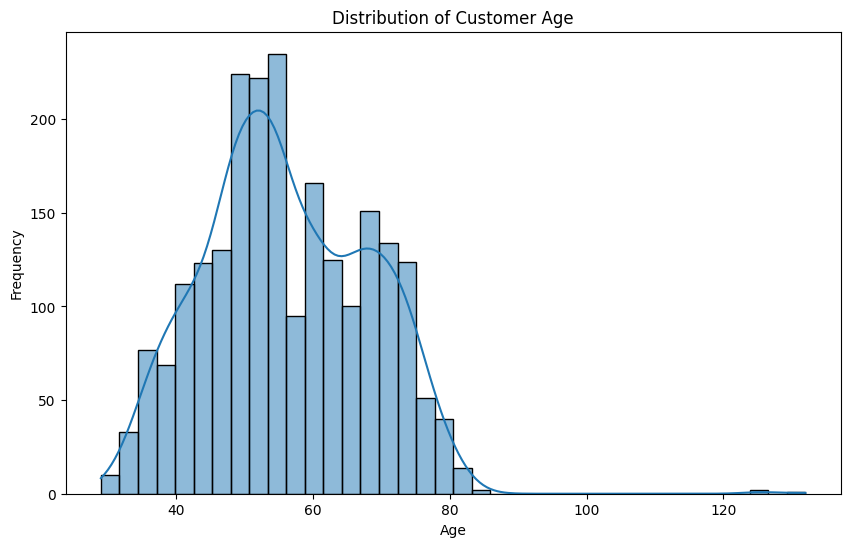

count    2240.000000
mean       56.194196
std        11.984069
min        29.000000
25%        48.000000
50%        55.000000
75%        66.000000
max       132.000000
Name: Age, dtype: float64


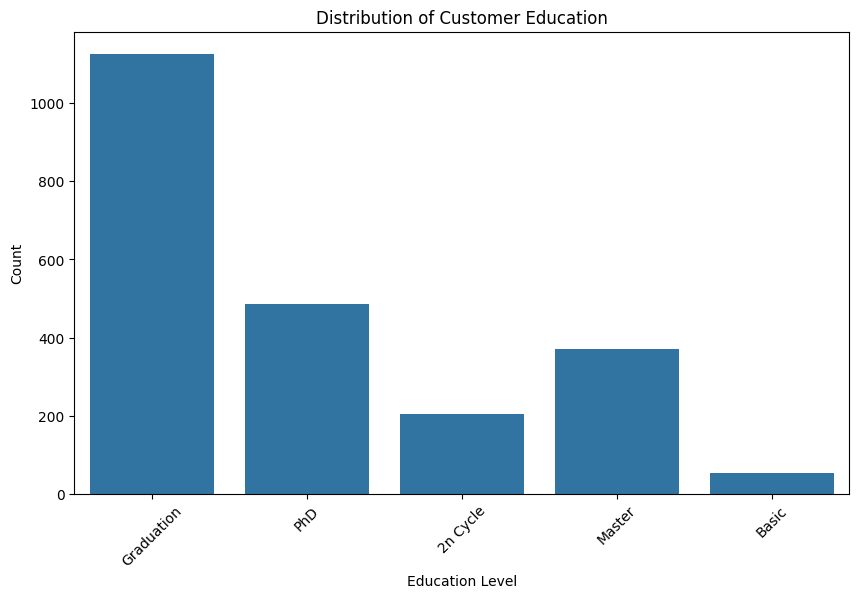

Education
Graduation    50.312500
PhD           21.696429
Master        16.517857
2n Cycle       9.062500
Basic          2.410714
Name: proportion, dtype: float64


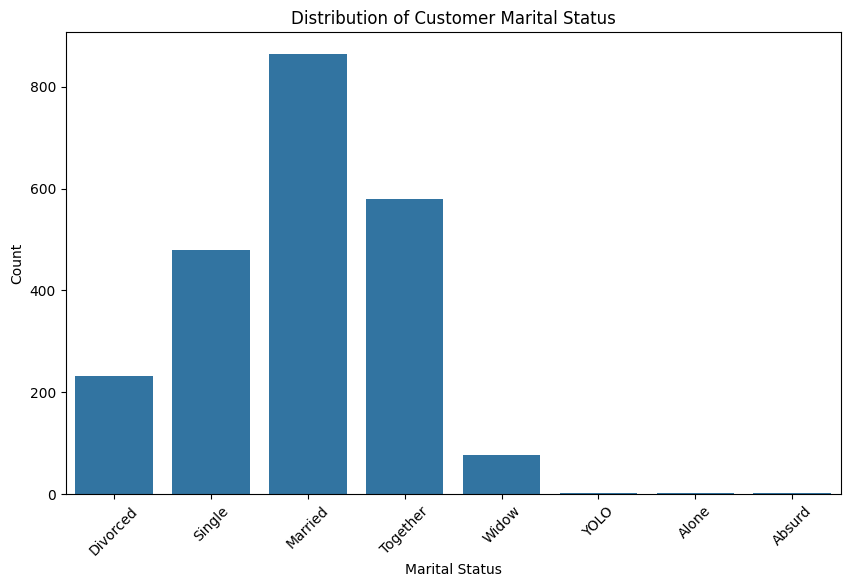

Marital_Status
Married     38.571429
Together    25.892857
Single      21.428571
Divorced    10.357143
Widow        3.437500
Alone        0.133929
YOLO         0.089286
Absurd       0.089286
Name: proportion, dtype: float64


In [104]:
# Analyze the distribution of customer demographics

# Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(PBA_df['Age'], kde=True)
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

print(PBA_df['Age'].describe())

# Education distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='Education', data=PBA_df)
plt.title('Distribution of Customer Education')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

print(PBA_df['Education'].value_counts(normalize=True) * 100)


# Marital status distribution
plt.figure(figsize=(10, 6))
# Check if the column name is 'Marital_Status' instead of 'Marital'
sns.countplot(x='Marital_Status', data=PBA_df)
plt.title('Distribution of Customer Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

print(PBA_df['Marital_Status'].value_counts(normalize=True) * 100) # Print with corrected column name if applicable

##Task 2 - Descriptive Statistics 📊

- **Calculate measures of central tendency (mean, median, mode) and measures of dispersion (variance, standard deviation) for key variables. Identify and handle outliers if necessary.**


**Deliverables**:

- **Descriptive statistics that reveal the central tendencies, variations, and potential outliers in the dataset.**:

In [105]:
#Descriptive statistics
# Select all numerical columns
numerical_cols = PBA_df.select_dtypes(include=['int64', 'float64']).columns

# Calculate descriptive statistics
statistics = {}

for col in numerical_cols:
    mean = PBA_df[col].mean()
    median = PBA_df[col].median()
    mode = PBA_df[col].mode()[0] if not PBA_df[col].mode().empty else np.nan
    variance = PBA_df[col].var()
    std_dev = PBA_df[col].std()

    statistics[col] = {
        'Mean': mean,
        'Median': median,
        'Mode': mode,
        'Variance': variance,
        'Standard Deviation': std_dev
    }

# Create DataFrame
stats_df = pd.DataFrame(statistics).T

# Show the table
display(stats_df)


,Mean,Median,Mode,Variance,Standard Deviation
Id,5592.159821,5458.5,0.0,1.054082e+07,3246.662198
Year_Birth,1968.805804,1970.0,1976.0,1.436179e+02,11.984069
Income,52237.975446,51381.5,51381.5,6.268992e+08,25037.955891
Kidhome,0.444196,0.0,0.0,2.898725e-01,0.538398
Teenhome,0.506250,0.0,0.0,2.965219e-01,0.544538
Recency,49.109375,49.0,56.0,8.388237e+02,28.962453
MntWines,303.935714,173.5,2.0,1.132978e+05,336.597393
MntFruits,26.302232,8.0,0.0,1.581926e+03,39.773434
MntMeatProducts,166.950000,67.0,7.0,5.094743e+04,225.715373
MntFishProducts,37.525446,12.0,0.0,2.984325e+03,54.628979


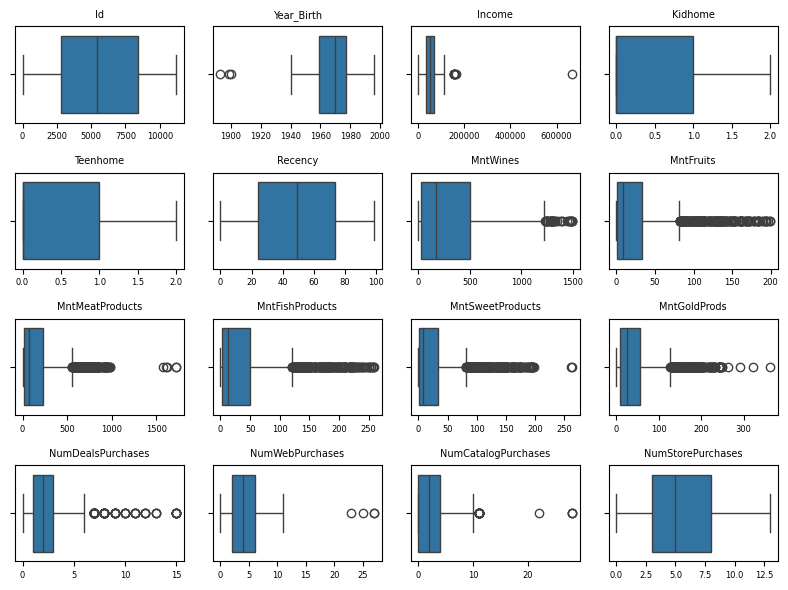

In [106]:
 #Box plot of outliers in various columns
# Select numerical columns (excluding 'ID')
numerical_cols = PBA_df.select_dtypes(include=['number']).drop(columns=['ID'], errors='ignore').columns[:16]

# Create 4x4 subplots with a much smaller figure size
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(8, 6))  # Much smaller
axes = axes.flatten()

# Create box plots
for i, col in enumerate(numerical_cols):
    sns.boxplot(x=PBA_df[col], ax=axes[i])
    axes[i].set_title(f'{col}', fontsize=7)
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=6)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


### **Finding method to be used for Outliers handling**

In [107]:
# Finding Best Method for Handling Outliers
# Select numerical columns for analysis
num_cols = PBA_df.select_dtypes(include=['float64', 'int64']).columns

# Initialize counters for outlier categories
mild_outlier_count = 0
severe_outlier_count = 0

# Helper functions for outlier detection
def calculate_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper, (column < lower) | (column > upper)

def calculate_outliers_zscore(column, threshold=3):
    z_scores = np.abs(stats.zscore(column, nan_policy='omit'))
    return z_scores > threshold

def apply_winsorization(column, lower_percentile=0.01, upper_percentile=0.99):
    lower_limit = column.quantile(lower_percentile)
    upper_limit = column.quantile(upper_percentile)
    return column.clip(lower=lower_limit, upper=upper_limit)

# Evaluation of all methods
outlier_details = {}

for col in num_cols:
    # IQR Method
    lower_iqr, upper_iqr, iqr_outliers = calculate_outliers_iqr(PBA_df[col])
    iqr_outlier_count = iqr_outliers.sum()

    # Z-Score Method
    zscore_outliers = calculate_outliers_zscore(PBA_df[col])
    zscore_outlier_count = zscore_outliers.sum()

    # Winsorization (applying capping)
    winsorized_column = apply_winsorization(PBA_df[col])
    winsorized_outliers = (PBA_df[col] != winsorized_column).sum()

    # Outlier ratio (outliers relative to non-null entries)
    total_non_null_entries = PBA_df[col].notna().sum()
    outlier_ratio_iqr = iqr_outlier_count / total_non_null_entries
    outlier_ratio_zscore = zscore_outlier_count / total_non_null_entries
    outlier_ratio_winsorization = winsorized_outliers / total_non_null_entries

    # Track results for decision making
    outlier_details[col] = {
        "IQR Outliers": iqr_outlier_count,
        "Z-Score Outliers": zscore_outlier_count,
        "Winsorization Outliers": winsorized_outliers,
        "Outlier Ratio IQR": outlier_ratio_iqr,
        "Outlier Ratio Z-Score": outlier_ratio_zscore,
        "Outlier Ratio Winsorization": outlier_ratio_winsorization
    }

# Total summary of outlier methods across all columns
total_outliers_iqr = sum([outlier_details[col]["IQR Outliers"] for col in num_cols])
total_outliers_zscore = sum([outlier_details[col]["Z-Score Outliers"] for col in num_cols])
total_outliers_winsorization = sum([outlier_details[col]["Winsorization Outliers"] for col in num_cols])

# Suggesting best method based on criteria
threshold_for_mild_outliers = 0.05
threshold_for_severe_outliers = 0.15

# Calculate the number of columns with outliers based on IQR, Z-Score, and Winsorization
mild_outliers = sum(1 for col in num_cols if outlier_details[col]["Outlier Ratio IQR"] > threshold_for_mild_outliers)
severe_outliers = sum(1 for col in num_cols if outlier_details[col]["Outlier Ratio IQR"] > threshold_for_severe_outliers)

# Decision logic considering business context and outlier severity
if severe_outliers > len(num_cols) * 0.3:
    print("Suggested outlier-handling method for PBA_df: Transformation (log/sqrt)")
elif mild_outliers > 0:
    # Adding business context: Retail/Purchasing market where extreme values represent genuine customers
    print("Suggested outlier-handling method for PBA_df: Winsorization (capping).")
    print("\n")
    print("""This is a retail/purchasing dataset, where extreme values often represent genuine high-spending customers,
and removing them could result in loss of important information. Hence, Winsorization is a more suitable approach.""")

else:
    print("Suggested outlier-handling method for PBA_df: No action needed")

# Displaying the summary of the outlier methods
print("\nOutlier detection summary across all numerical columns:")
print(f"Total Outliers (IQR): {total_outliers_iqr}")
print(f"Total Outliers (Z-Score): {total_outliers_zscore}")
print(f"Total Outliers (Winsorization): {total_outliers_winsorization}")


Suggested outlier-handling method for PBA_df: Winsorization (capping).


This is a retail/purchasing dataset, where extreme values often represent genuine high-spending customers, 
and removing them could result in loss of important information. Hence, Winsorization is a more suitable approach.

Outlier detection summary across all numerical columns:
Total Outliers (IQR): 1605
Total Outliers (Z-Score): 365
Total Outliers (Winsorization): 450


###**Handling Outliers**

In [108]:
# Winsozarion for handling Outliers
def winsorize_outliers(df, columns, limits=(0.05, 0.95)):
    """Applies Winsorization to specified columns in a DataFrame."""
    df_winsorized = df.copy()
    for col in columns:
        lower = df[col].quantile(limits[0])
        upper = df[col].quantile(limits[1])
        df_winsorized[col] = np.clip(df[col], lower, upper)
    return df_winsorized

columns_to_winsorize = [
    'Income', 'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
    'NumStorePurchases', 'NumWebVisitsMonth', 'Recency', 'Age'
]

PBA_df_winsorized = winsorize_outliers(PBA_df, columns_to_winsorize)


###**Box plot after handling Outliers**

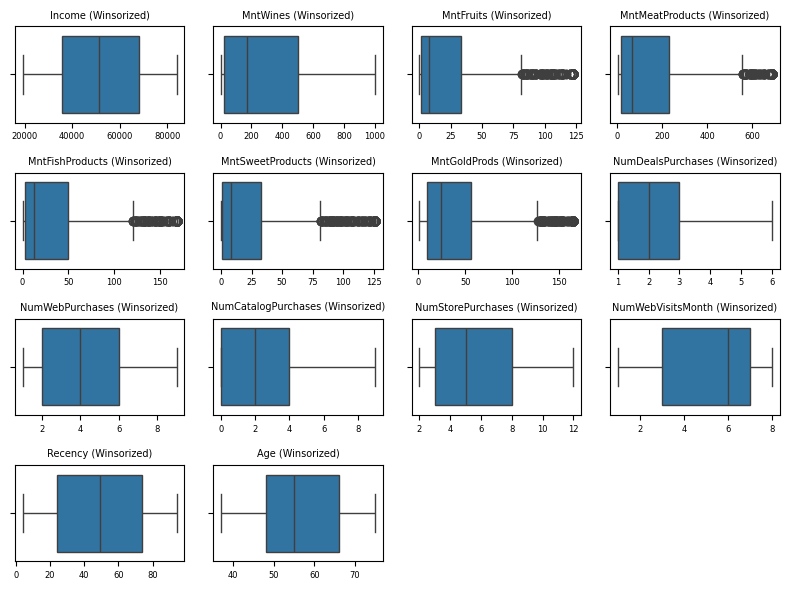

In [109]:
# Create subplots for box plots after winsorization
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(8, 6))
axes = axes.flatten()

# Iterate through numerical columns and create box plots for winsorized data
for i, col in enumerate(columns_to_winsorize):
    if i < len(axes):
        sns.boxplot(x=PBA_df_winsorized[col], ax=axes[i])
        axes[i].set_title(f'{col} (Winsorized)', fontsize=7)
        axes[i].set_xlabel('')
        axes[i].tick_params(labelsize=6)
    else:
        break

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


###**Descriptive Statistics comparison after Winsorization**

In [110]:
# Descriptive statistic comparison before and after handling outliers
# Select numerical columns
numerical_cols = PBA_df.select_dtypes(include=['int64', 'float64']).columns

# Helper function to compute statistics
def get_statistics(df):
    stats = {}
    for col in numerical_cols:
        mode_val = df[col].mode()[0] if not df[col].mode().empty else np.nan
        stats[col] = {
            'Mean': df[col].mean(),
            'Median': df[col].median(),
            'Mode': mode_val,
            'Variance': df[col].var(),
            'Standard Deviation': df[col].std()
        }
    return pd.DataFrame(stats).T

# Stats before Winsorization
stats_before = get_statistics(PBA_df)

# Apply Winsorization (limit 5% on each side)
winsorized_df = PBA_df.copy()
for col in numerical_cols:
    winsorized_data = winsorize(PBA_df[col], limits=[0.05, 0.05])
    winsorized_df[col] = winsorized_data

# Stats after Winsorization
stats_after = get_statistics(winsorized_df)

# Combine both
combined_stats = pd.DataFrame()
for stat in ['Mean', 'Median', 'Mode', 'Variance', 'Standard Deviation']:
    combined_stats[f'{stat} (Before)'] = stats_before[stat]
    combined_stats[f'{stat} (After)'] = stats_after[stat]

# Display the final comparison table
display(combined_stats)


,Mean (Before),Mean (After),Median (Before),Median (After),Mode (Before),Mode (After),Variance (Before),Variance (After),Standard Deviation (Before),Standard Deviation (After)
Id,5592.159821,5594.921875,5458.5,5458.5,0.0,577.0,1.054082e+07,1.026318e+07,3246.662198,3203.619651
Year_Birth,1968.805804,1968.910714,1970.0,1970.0,1976.0,1950.0,1.436179e+02,1.260715e+02,11.984069,11.228158
Income,52237.975446,51743.179911,51381.5,51381.5,51381.5,19107.0,6.268992e+08,3.857132e+08,25037.955891,19639.582044
Kidhome,0.444196,0.422768,0.0,0.0,0.0,0.0,2.898725e-01,2.441442e-01,0.538398,0.494109
Teenhome,0.506250,0.483036,0.0,0.0,0.0,0.0,2.965219e-01,2.498237e-01,0.544538,0.499824
Recency,49.109375,49.094643,49.0,49.0,56.0,4.0,8.388237e+02,8.150344e+02,28.962453,28.548807
MntWines,303.935714,295.352679,173.5,173.5,2.0,3.0,1.132978e+05,9.869085e+04,336.597393,314.151003
MntFruits,26.302232,24.774107,8.0,8.0,0.0,0.0,1.581926e+03,1.215066e+03,39.773434,34.857790
MntMeatProducts,166.950000,159.041964,67.0,67.0,7.0,4.0,5.094743e+04,3.944467e+04,225.715373,198.606827
MntFishProducts,37.525446,35.656696,12.0,12.0,0.0,0.0,2.984325e+03,2.391898e+03,54.628979,48.907031


## Task 3 - Probability Distributions 🎲

- **Identify variables that could follow specific probability distributions (e.g., Binomial, Normal). Calculate probabilities and expected values based on these distributions.**



**Deliverables**:

- **Determination of suitable probability distributions for relevant variables and corresponding calculated probabilities and expected values.**:

  

📌 Bernoulli Distribution: Binary Variables



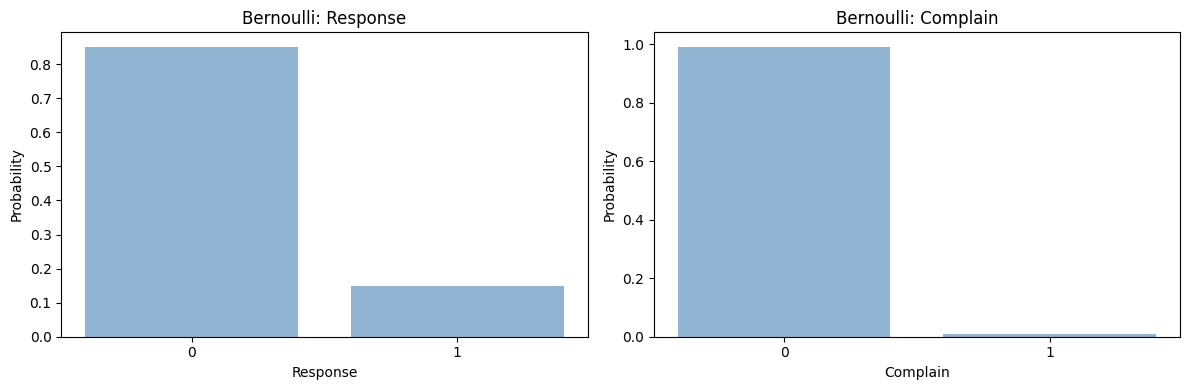

📌 Normal Distribution: Spend Variables



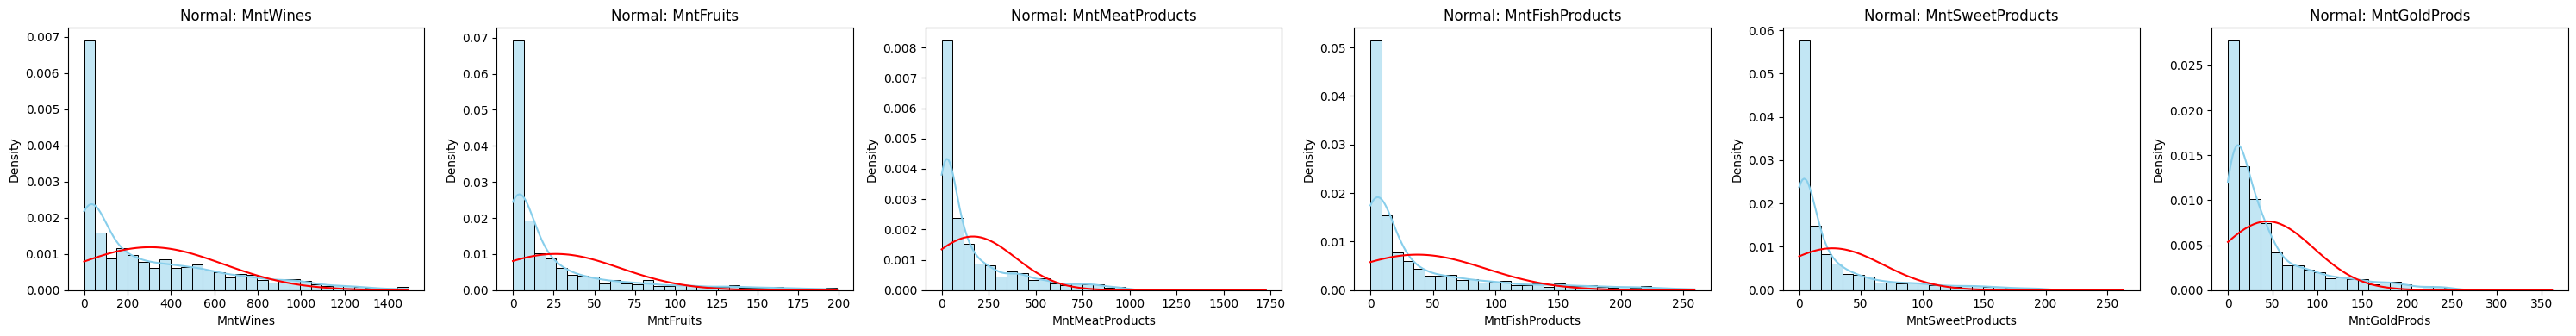

📌 Poisson Distribution: Count Variables



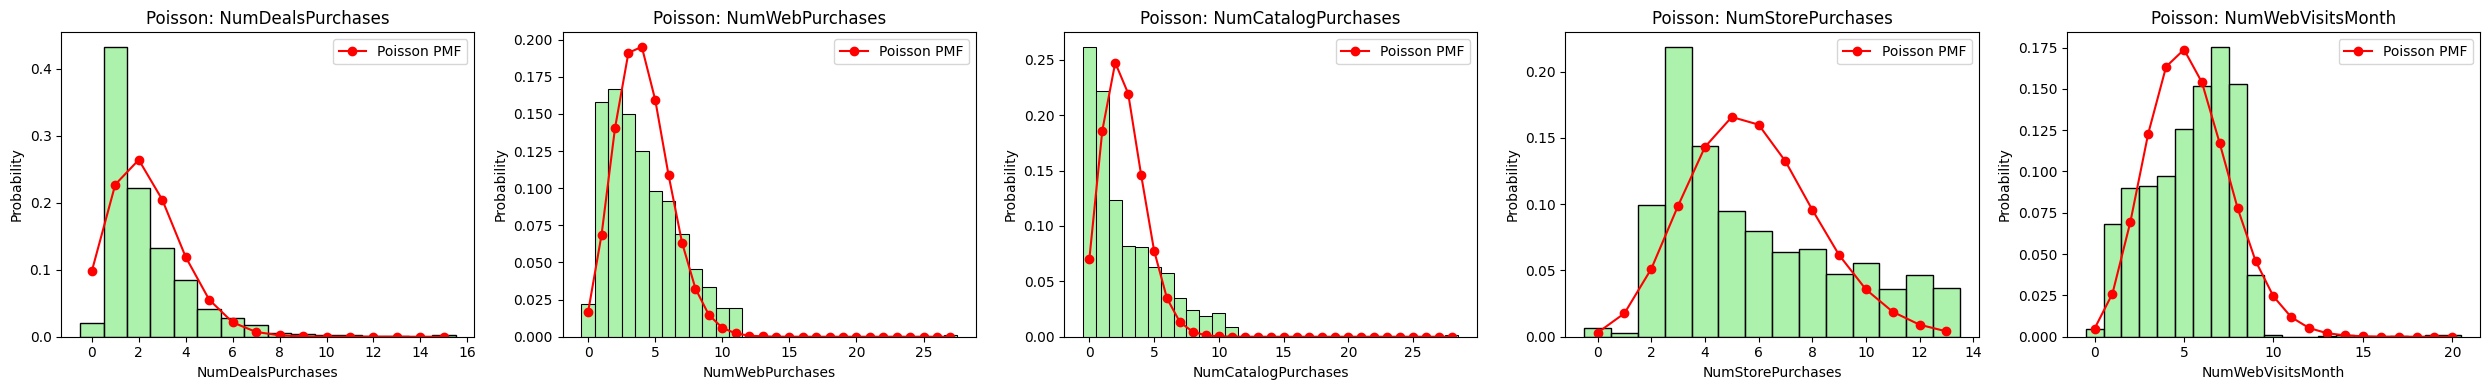

📌 Categorical Distribution: Education and Marital Status



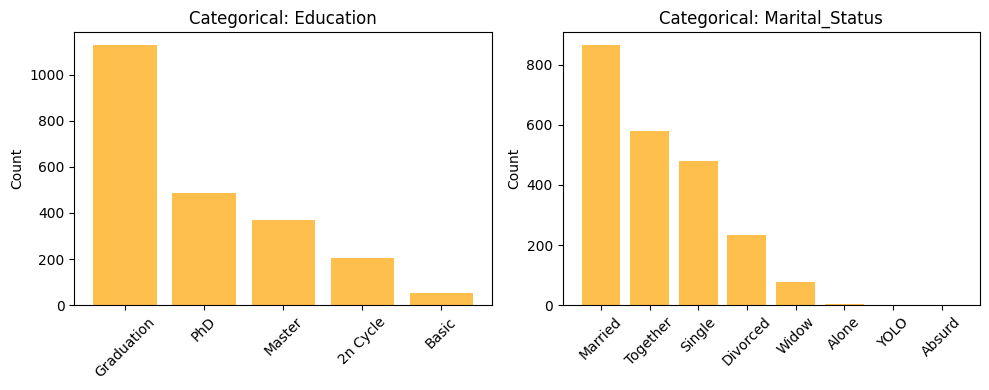

📌 Demographic Variables: Income, Age, Recency, Kidhome, Teenhome



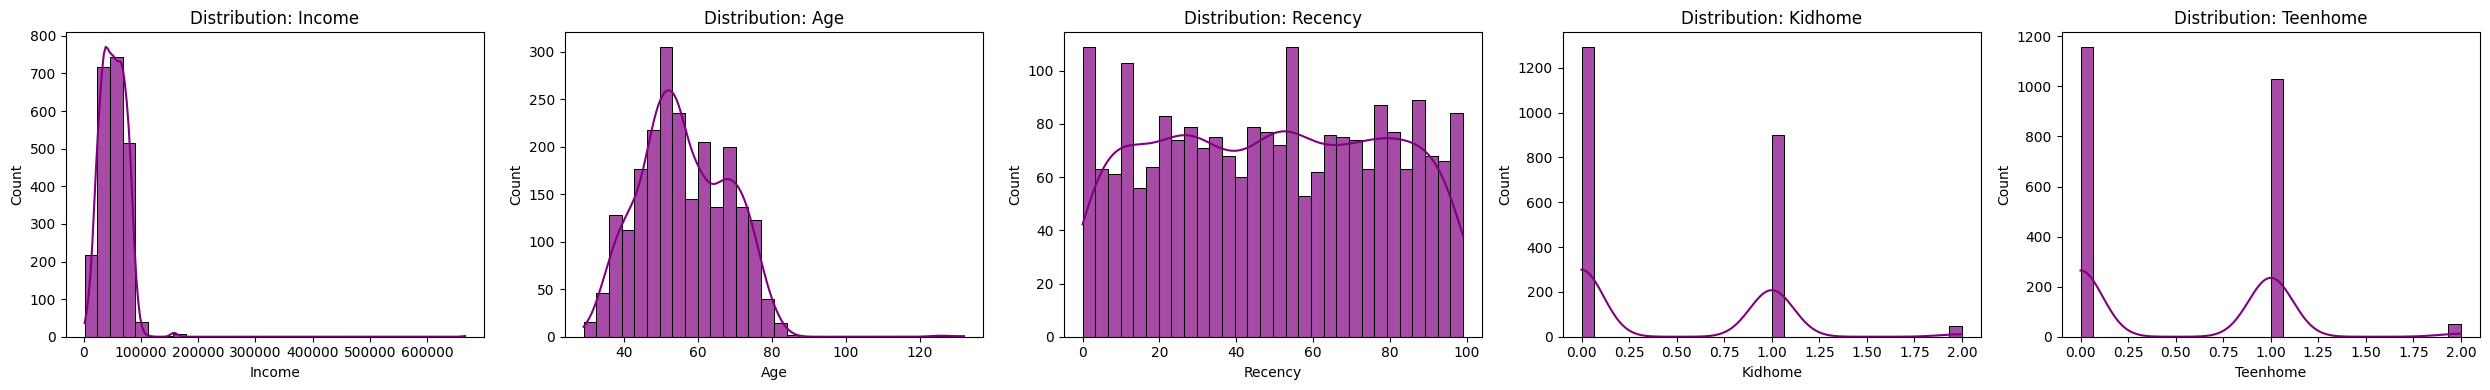

📌 Exponential Fit: Recency



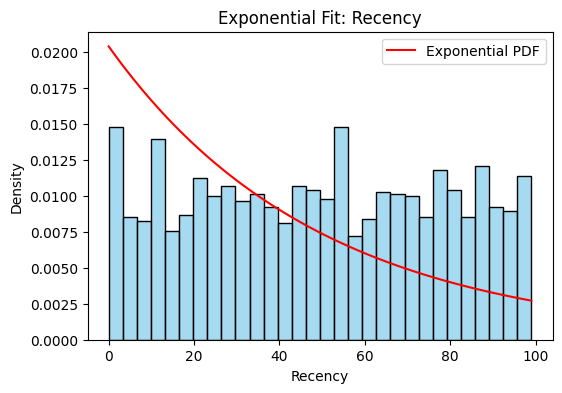

In [123]:
#Probability Distributions
df = PBA_df  # Using your DataFrame

# ---------------------------
# 1. Bernoulli Distribution
# ---------------------------
print("📌 Bernoulli Distribution: Binary Variables\n")
binary_vars = ['Response', 'Complain']
fig, axs = plt.subplots(1, len(binary_vars), figsize=(6 * len(binary_vars), 4))

for i, var in enumerate(binary_vars):
    data = df[var].dropna()
    if data.nunique() > 1:
        prob = data.mean()
        pmf = stats.bernoulli.pmf([0, 1], prob)

        axs[i].bar([0, 1], pmf, alpha=0.6, color='steelblue')
        axs[i].set_title(f'Bernoulli: {var}')
        axs[i].set_xlabel(var)
        axs[i].set_ylabel('Probability')
        axs[i].set_xticks([0, 1])

plt.tight_layout()
plt.show()

# ---------------------------
# 2. Normal Distribution
# ---------------------------
print("📌 Normal Distribution: Spend Variables\n")
normal_vars = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
fig, axs = plt.subplots(1, len(normal_vars), figsize=(5 * len(normal_vars), 4))

for i, var in enumerate(normal_vars):
    data = df[var].dropna()
    mean, std = data.mean(), data.std()
    sns.histplot(data, kde=True, stat='density', bins=30, ax=axs[i], color='skyblue')
    x = np.linspace(data.min(), data.max(), 100)
    axs[i].plot(x, stats.norm.pdf(x, mean, std), 'r')
    axs[i].set_title(f'Normal: {var}')
    axs[i].set_xlabel(var)

plt.tight_layout()
plt.show()

# ---------------------------
# 3. Poisson Distribution
# ---------------------------
print("📌 Poisson Distribution: Count Variables\n")
poisson_vars = ['NumDealsPurchases', 'NumWebPurchases',
                'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']
fig, axs = plt.subplots(1, len(poisson_vars), figsize=(5 * len(poisson_vars), 4))

for i, var in enumerate(poisson_vars):
    data = df[var].dropna()
    lam = data.mean()
    values = np.arange(data.min(), data.max() + 1)
    probs = stats.poisson.pmf(values, mu=lam)

    sns.histplot(data, stat='probability', bins=len(values), discrete=True, color='lightgreen', ax=axs[i])
    axs[i].plot(values, probs, 'o-', color='red', label='Poisson PMF')
    axs[i].set_title(f'Poisson: {var}')
    axs[i].set_xlabel(var)
    axs[i].legend()

plt.tight_layout()
plt.show()

# ---------------------------
# 4. Categorical Variables
# ---------------------------
print("📌 Categorical Distribution: Education and Marital Status\n")
categorical_vars = ['Education', 'Marital_Status']
fig, axs = plt.subplots(1, len(categorical_vars), figsize=(5 * len(categorical_vars), 4))

for i, var in enumerate(categorical_vars):
    counts = df[var].value_counts()
    axs[i].bar(counts.index, counts.values, color='orange', alpha=0.7)
    axs[i].set_title(f'Categorical: {var}')
    axs[i].set_ylabel('Count')
    axs[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ---------------------------
# 5. Demographic Distributions
# ---------------------------
print("📌 Demographic Variables: Income, Age, Recency, Kidhome, Teenhome\n")
demographic_vars = ['Income', 'Age', 'Recency', 'Kidhome', 'Teenhome']
fig, axs = plt.subplots(1, len(demographic_vars), figsize=(5 * len(demographic_vars), 4))

for i, var in enumerate(demographic_vars):
    sns.histplot(df[var].dropna(), bins=30, kde=True, color='purple', ax=axs[i], alpha=0.7)
    axs[i].set_title(f'Distribution: {var}')
    axs[i].set_xlabel(var)

plt.tight_layout()
plt.show()

# ---------------------------
# 6. Exponential Fit for Recency
# ---------------------------
print("📌 Exponential Fit: Recency\n")
fig, ax = plt.subplots(figsize=(6, 4))
recency_data = df['Recency'].dropna()
scale = recency_data.mean()

sns.histplot(recency_data, stat='density', bins=30, color='skyblue', ax=ax)
x = np.linspace(0, recency_data.max(), 100)
ax.plot(x, stats.expon.pdf(x, scale=scale), 'r', label='Exponential PDF')
ax.set_title('Exponential Fit: Recency')
ax.set_xlabel('Recency')
ax.set_ylabel('Density')
ax.legend()
plt.show()


###**Calculate probabilities and expected values based on these distributions.**

In [129]:
#Probability Calculation
df = PBA_df
results = []

# Helper function to append results with interpretation
def append_result(dist, var, prob, exp_val, interpretation):
    results.append({
        'Distribution': dist,
        'Variable': var,
        'Probability': prob,
        'Expected Value': exp_val,
        'Interpretation': interpretation
    })

# 1. Bernoulli
for var in ['Response', 'Complain']:
    data = df[var].dropna()
    if data.nunique() > 1:
        p = data.mean()
        append_result('Bernoulli', var, p, p, 'Probability of event (Yes = 1)')

# 2. Normal
for var in ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']:
    data = df[var].dropna()
    append_result('Normal', var, None, data.mean(), 'Avg spend (₹/Customer)')

# 3. Poisson
for var in ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']:
    data = df[var].dropna()
    append_result('Poisson', var, None, data.mean(), 'Avg count (/Customer)')

# 4. Categorical
for var in ['Education', 'Marital_Status']:
    counts = df[var].value_counts()
    probs = counts / counts.sum()
    append_result('Categorical', var, probs.to_dict(), 'N/A', 'Probability distribution of categories')

# 5. Demographics
for var in ['Income', 'Age', 'Recency', 'Kidhome', 'Teenhome']:
    data = df[var].dropna()
    probs = stats.gaussian_kde(data)(data)
    interpretation = 'Mean value (/Customer)' if var not in ['Kidhome', 'Teenhome'] else 'Avg count (/Customer)'
    append_result('Demographic', var, probs[:5], data.mean(), interpretation)

# 6. Exponential
recency = df['Recency'].dropna()
append_result('Exponential', 'Recency', None, recency.mean(), 'Avg recency (/Customer)')

# Output
results_df = pd.DataFrame(results)
print(tabulate(results_df, headers='keys', tablefmt='pretty', showindex=False))


+--------------+---------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------------------+----------------------------------------+
| Distribution |      Variable       |                                                                                                                     Probability                                                                                                                      |   Expected Value    |             Interpretation             |
+--------------+---------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------